In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("KerasTuner version:", kt.__version__)

TensorFlow version: 2.20.0-rc0
KerasTuner version: 1.4.7


In [18]:
# Phase 1: Initial Data Loading and Preprocessing
# 1. Load dataset
file_path = 'nTop/Generated Data.csv'
try:
    data = pd.read_csv(file_path)
    print("Data loaded successfully.")
    print("First 5 rows of the dataset:")
    print(data.head())
    print("\nDataset Info:")
    data.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please make sure the CSV file is in the 'nTop' directory.")

Data loaded successfully.
First 5 rows of the dataset:
   AvgVelocity        Mass  PressureDrop  Surface Area  Velocity Inlet  \
0   503.737375  155.865004   7313.211948   34714.82646     2500.000000   
1   525.829709  155.865004   8075.659593   34714.82646     2611.111111   
2   546.193480  155.865004   8637.255733   34714.82646     2722.222222   
3   567.558751  155.865004   9258.511486   34714.82646     2833.333333   
4   592.409907  155.865004  10251.007620   34714.82646     2944.444444   

   X Cell Size  YZ Cell Size  
0         10.0          10.0  
1         10.0          10.0  
2         10.0          10.0  
3         10.0          10.0  
4         10.0          10.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AvgVelocity     1000 non-null   float64
 1   Mass            1000 non-null   float64
 2   PressureD

In [19]:
# 2. Separate features and targets
features = ['X Cell Size', 'YZ Cell Size', 'Velocity Inlet']
targets = ['PressureDrop', 'AvgVelocity', 'Surface Area', 'Mass']

X = data[features]
y = data[targets]

# 3. Standardize inputs & outputs using MinMaxScaler
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

print("Features and targets separated and scaled with MinMaxScaler.")

Features and targets separated and scaled with MinMaxScaler.


In [20]:
# 4. Split data
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.1, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")

Training data shape: (900, 3)
Validation data shape: (100, 3)


In [21]:
# Phase 2: Baseline MLP Model Training (Keras) with Keras Tuner

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    # Tune the number of layers
    for i in range(hp.Int('num_layers', 2, 6)):
        # Tune the number of units in each layer
        model.add(layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=1024, step=64),
                               activation=hp.Choice(f'activation_{i}', ['relu', 'tanh', 'elu'])))
        # Add dropout for regularization
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    model.add(layers.Dense(y_train.shape[1])) # Output layer
    
    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 5e-5])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error',
                  metrics=['mean_absolute_error'])
    
    return model

In [22]:
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=100,
                     factor=3,
                     directory='keras_tuner_dir',
                     project_name='asme_hackathon')

# Create a callback to stop training early after reaching a certain value for the validation loss.
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Start the search
tuner.search(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of layers is {best_hps.get('num_layers')} 
and the optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

Trial 254 Complete [00h 00m 09s]
val_loss: 0.002930581569671631

Best val_loss So Far: 0.0006604373338632286
Total elapsed time: 00h 14m 08s

The hyperparameter search is complete. The optimal number of layers is 4 
and the optimal learning rate for the optimizer is 0.0001.



In [23]:
# Build the model with the optimal hyperparameters and train it on the data
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[stop_early])

val_loss = history.history['val_loss']
best_epoch = val_loss.index(min(val_loss)) + 1
print(f'Best epoch: {best_epoch}')

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1494 - mean_absolute_error: 0.3228 - val_loss: 0.1011 - val_mean_absolute_error: 0.2523
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0693 - mean_absolute_error: 0.2029 - val_loss: 0.0542 - val_mean_absolute_error: 0.1819
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0439 - mean_absolute_error: 0.1585 - val_loss: 0.0388 - val_mean_absolute_error: 0.1404
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0333 - mean_absolute_error: 0.1276 - val_loss: 0.0316 - val_mean_absolute_error: 0.1202
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0276 - mean_absolute_error: 0.1131 - val_loss: 0.0265 - val_mean_absolute_error: 0.1093
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0230 - mean_absolute_error: 0.1026 - val_loss: 0.0219 - val_mean_absolute_error: 0.0994
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0189 - mean_absolute_error: 0.0929 - val_loss

In [24]:
hypermodel = tuner.hypermodel.build(best_hps)

# Retrain the model
hypermodel.fit(X_train, y_train, epochs=best_epoch)

eval_result = hypermodel.evaluate(X_val, y_val)
print(f"[test loss, test accuracy]: {eval_result}")

Epoch 1/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1401 - mean_absolute_error: 0.3014   
Epoch 2/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0615 - mean_absolute_error: 0.1864 
Epoch 3/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0419 - mean_absolute_error: 0.1457 
Epoch 4/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0328 - mean_absolute_error: 0.1248 
Epoch 5/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0266 - mean_absolute_error: 0.1109 
Epoch 6/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0214 - mean_absolute_error: 0.0982 
Epoch 7/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0166 - mean_absolute_error: 0.0865 
Epoch 8/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0125 - mean_absolute_error: 0.0746 
Epoch 9/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0091 - mean_absolute_error: 0.0641 
Epoch 10/98
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0065 - mean_absolute_error: 0.0541 
Epoch 11/98
29/29 ━━━━━━━━━━━━━━━━━━━

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Mean Absolute Error for each target:
PressureDrop: 293.1643
AvgVelocity: 8.7900
Surface Area: 324.6581
Mass: 0.4311
Mean Absolute Error for each target:
PressureDrop: 293.1643
AvgVelocity: 8.7900
Surface Area: 324.6581
Mass: 0.4311


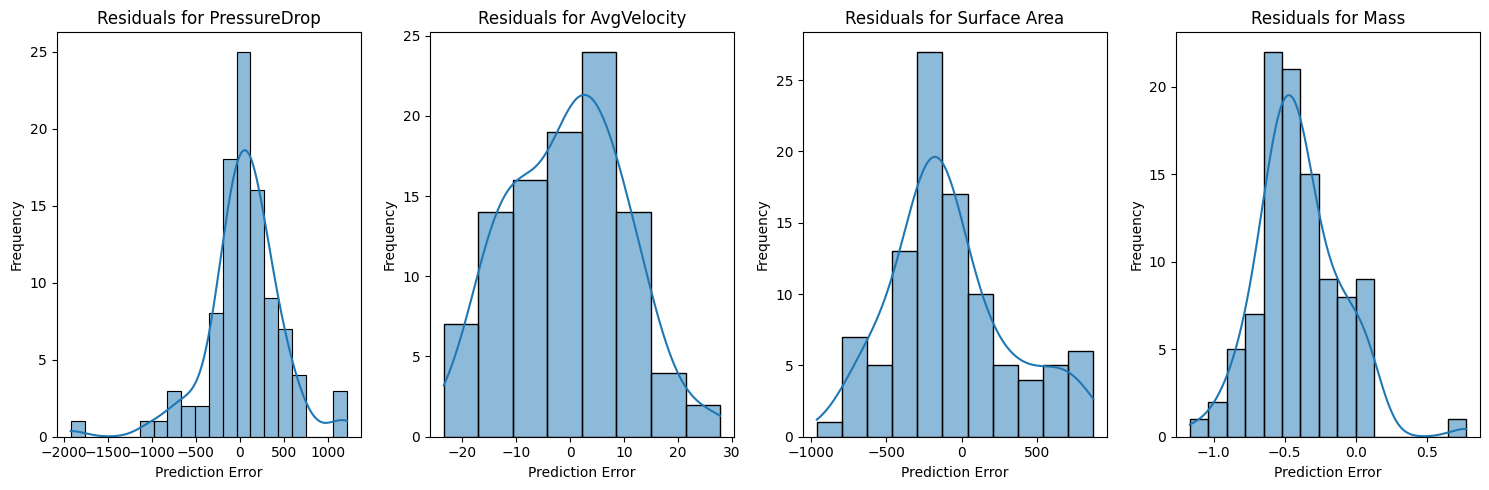

In [25]:
# Phase 2: Targeted Sampling & Model Refinement
# 1. Analyze Baseline Residuals
y_pred_scaled = hypermodel.predict(X_val)
residuals_scaled = y_val - y_pred_scaled

# Inverse transform to get original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_val_orig = scaler_y.inverse_transform(y_val)
residuals = y_val_orig - y_pred

# Calculate Mean Absolute Error for each target
mae_per_target = np.mean(np.abs(residuals), axis=0)
print("Mean Absolute Error for each target:")
for i, target in enumerate(targets):
    print(f"{target}: {mae_per_target[i]:.4f}")

# Visualize residuals
plt.figure(figsize=(15, 5))
for i, target in enumerate(targets):
    plt.subplot(1, len(targets), i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals for {target}')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Top 100 validation points with highest prediction error:
   X Cell Size  YZ Cell Size  Velocity Inlet
0    20.000000     21.666667     3500.000000
1    25.000000     23.333333     3166.666667
2    21.666667     23.333333     3277.777778
3    20.000000     21.666667     3388.888889
4    10.000000     15.000000     2500.000000
5    11.666667     10.000000     3277.777778
6    10.000000     18.333333     3500.000000
7    23.333333     25.000000     3500.000000
8    10.000000     23.333333     3388.888889
9    10.000000     25.000000     3166.666667


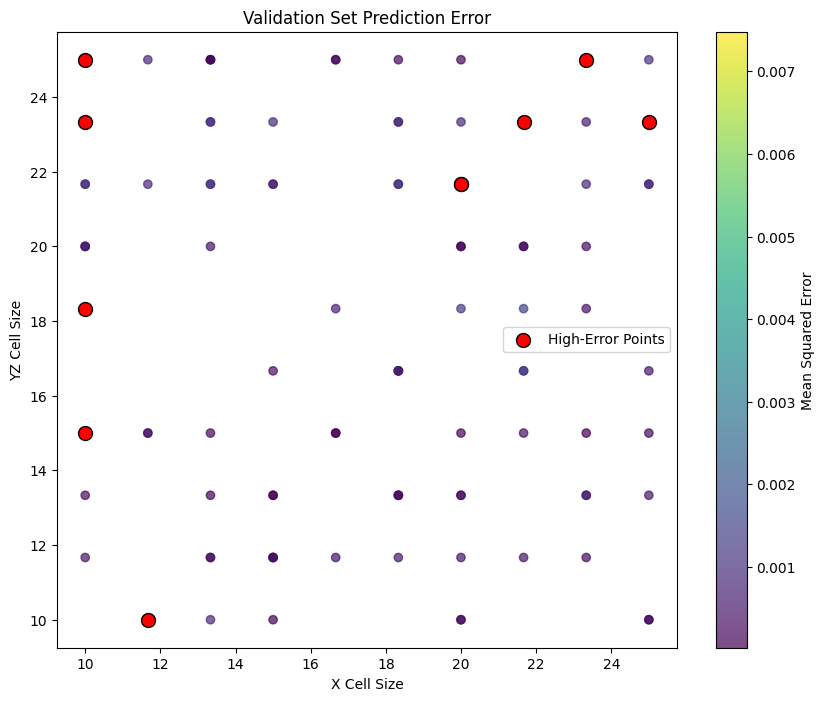

In [26]:
# Identify high-error regions
# We'll use the mean squared error of the scaled residuals to identify the points with the highest error.
mse_per_point = np.mean(np.square(residuals_scaled), axis=1)
# Get top 100 high-error points, or all if less than 100 are available
num_points = min(100, len(X_val))
high_error_indices = np.argsort(mse_per_point)[-10:] 

print(f"Top {num_points} validation points with highest prediction error:")
X_val_orig = scaler_X.inverse_transform(X_val)
high_error_inputs = X_val_orig[high_error_indices]
print(pd.DataFrame(high_error_inputs, columns=features))

# Visualize high-error regions
plt.figure(figsize=(10, 8))
sc = plt.scatter(X_val_orig[:, 0], X_val_orig[:, 1], c=mse_per_point, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Mean Squared Error')
plt.scatter(high_error_inputs[:, 0], high_error_inputs[:, 1], color='red', s=100, edgecolor='black', label='High-Error Points')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title('Validation Set Prediction Error')
plt.legend()
plt.show()

In [28]:
import pickle

# Save the trained model and scalers to pickle files
with open('trained_model.pkl', 'wb') as f:
    pickle.dump(hypermodel, f)

with open('scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)
